# 🐼 Pandas Project: E-Commerce Sales & Customer Analytics System

This is a **company-level Pandas project** designed to take you from **basic → intermediate → advanced data analysis** while using the Pandas concepts you are learning:



An e-commerce company stores its business information in multiple datasets. However, the information is distributed across different files.

The company wants to build a **Pandas-based Business Analytics System** that combines these datasets and generates meaningful business insights.

Your task is to clean, transform, combine, and analyze the datasets using **Pandas**.

The final system should answer questions such as:

```text
Who are the most valuable customers?

Which products generate the highest revenue?

Which categories are performing best?

Which cities generate the most sales?

Which month has the highest revenue?

What is the company's total profit?

Which products have high sales but low profit?

Which customers should be considered VIP customers?
```


# 📂 Dataset Information

You will work with **4 related datasets**.

```text
Customers
    │
    ├──────────────┐
    ↓              ↓
Orders          Customers
    │
    ↓
Products
    │
    ↓
Payments
```

The datasets are connected using IDs such as:

```text
Customer_ID
Product_ID
Order_ID
Payment_ID
```




# 🧮 Important Calculated Columns

After combining the datasets, create additional columns.

## Revenue

```text
Revenue = Price × Quantity
```

In Pandas:

```python
df["Revenue"] = df["Price"] * df["Quantity"]
```

## Total Cost

```text
Total Cost = Cost_Price × Quantity
```

## Profit

```text
Profit =
Revenue
- Total Cost
- Discount
- Shipping Cost
```

## Profit Margin

```text
Profit Margin =
(Profit / Revenue) × 100
```

These calculated columns will become the foundation for your business analysis.




In [1]:
import pandas as pd
import numpy as np

In [2]:
customers = pd.read_csv('Datasets/customers.csv')
orders = pd.read_csv('Datasets/orders.csv')
products = pd.read_csv('Datasets/products.csv')
payments = pd.read_csv('Datasets/payments.csv')

In [3]:
customers.head()

,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date
0,C000001,Ravi Mehta,Male,32.0,Pune,Maharashtra,2020-01-01
1,C000002,Shreya Mehta,Female,42.0,Chennai,Tamil Nadu,2020-01-01
2,C000003,Ishita Mehta,Female,33.0,Ludhiana,Punjab,2020-01-01
3,C000004,Pallavi Chopra,Female,21.0,Nagpur,Maharashtra,2020-01-01
4,C000005,Gaurav Kumar,Male,26.0,Kolkata,West Bengal,2020-01-01


In [4]:
orders.head()

,Order_ID,Customer_ID,Product_ID,Order_Date,Quantity,Payment_ID
0,OR000001,C298262,PR588891,2024-01-01,6.0,PAY419267
1,OR000002,C561401,PR382461,2024-01-01,9.0,PAY528701
2,OR000003,C562762,PR554955,2024-01-01,4.0,PAY280872
3,OR000004,C316618,PR060076,2024-01-01,1.0,PAY327324
4,OR000005,C345449,PR559586,2024-01-01,3.0,PAY359332


In [5]:
products.head()

,Product_ID,Product_Name,Category,Subcategory,Price,Cost_Price
0,PR000001,Coffee Table 7286,Furniture,Living Room,1005.0,889.2015343569917
1,PR000002,Lipstick 338,Beauty & Personal Care,Makeup,71.0,60.6168946090633
2,PR000003,Biscuits 760,Groceries,Snacks,10386.0,6949.720032174632
3,PR000004,Feature Phone 9928,Electronics,Mobile Phones,79196.0,52120.26481073169
4,PR000005,t-shirt 666,Clothing,Men,1061.0,839.5840391826301


In [6]:
payments.head()

,Payment_ID,Payment_Method,Payment_Status,Discount,Shipping_Cost
0,PAY000001,UPI,Successful,205.0,2.0
1,PAY000002,UPI,Successful,1356.0,69.0
2,PAY000003,UPI,Successful,157.0,237.0
3,PAY000004,Wallet,Failed,150.0,31.0
4,PAY000005,Cash,Pending,178.0,184.0


In [7]:
print(customers.size)
print(orders.size)
print(products.size)
print(payments.size)

4200000
3900000
3600000
3250000


In [8]:
main = ((customers.merge(orders,on='Customer_ID')).merge(products,on='Product_ID')).merge(payments,on='Payment_ID')
main.head()

,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date,Order_ID,Product_ID,Order_Date,...,Payment_ID,Product_Name,Category,Subcategory,Price,Cost_Price,Payment_Method,Payment_Status,Discount,Shipping_Cost
0,C000001,Ravi Mehta,Male,32.0,Pune,Maharashtra,2020-01-01,OR209117,PR502357,2024-11-02,...,PAY292974,Kajal 9556,Beauty & Personal Care,Makeup,76.0,54.14997095553045,UPI,Refunded,213.0,9.0
1,C000002,Shreya Mehta,Female,42.0,Chennai,Tamil Nadu,2020-01-01,OR555982,PR208664,2026-03-25,...,PAY056847,Drone 2665,Toys & Games,Remote Control,18166.0,13944.044265232484,Net Banking,Successful,2487.0,46.0
2,C000003,Ishita Mehta,Female,33.0,Ludhiana,Punjab,2020-01-01,OR546714,PR594215,2026-03-11,...,PAY213964,Blender 9427,Furniture,Kitchen,277.0,170.90436295314794,Credit Card,Successful,252.0,160.0
3,C000008,Nisha Kaur,Female,37.0,Hyderabad,Telangana,2020-01-01,OR109914,PR338402,2024-06-09,...,PAY014851,Webcam 2513,Electronics,Cameras,102.0,61.86470925064904,Credit Card,Successful,211.0,34.0
4,C000009,Nisha Gupta,Female,47.0,Bhubaneswar,Odisha,2020-01-01,OR299486,PR412685,2025-03-14,...,PAY594017,Cricket Bat 8042,Sports & Outdoors,Team Sports,1041.0,580.0423162317597,Credit Card,Successful,2806.0,350.0


In [9]:
main.isna().sum()

Customer_ID              0
Customer_Name        18031
Gender               12048
Age                   5963
City                  8888
State                 8815
Registration_Date    11730
Order_ID                 0
Product_ID               0
Order_Date            8878
Quantity              8912
Payment_ID               0
Product_Name         11895
Category              8889
Subcategory           9088
Price                10513
Cost_Price            8714
Payment_Method       11593
Payment_Status       11752
Discount             10324
Shipping_Cost         7092
dtype: int64

In [10]:
main.info()

<class 'pandas.DataFrame'>
RangeIndex: 596740 entries, 0 to 596739
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Customer_ID        596740 non-null  str    
 1   Customer_Name      578709 non-null  str    
 2   Gender             584692 non-null  str    
 3   Age                590777 non-null  str    
 4   City               587852 non-null  str    
 5   State              587925 non-null  str    
 6   Registration_Date  585010 non-null  str    
 7   Order_ID           596740 non-null  str    
 8   Product_ID         596740 non-null  str    
 9   Order_Date         587862 non-null  str    
 10  Quantity           587828 non-null  str    
 11  Payment_ID         596740 non-null  str    
 12  Product_Name       584845 non-null  str    
 13  Category           587851 non-null  str    
 14  Subcategory        587652 non-null  str    
 15  Price              586227 non-null  float64
 16  Cost_Price   

In [11]:
main['Age'] = pd.to_numeric(main['Age'],errors='coerce')
main["Quantity"] = pd.to_numeric(main["Quantity"], errors="coerce")
main["Cost_Price"] = pd.to_numeric(main["Cost_Price"], errors="coerce")
main["Shipping_Cost"] = pd.to_numeric(main["Shipping_Cost"], errors="coerce")

In [12]:
main.info()

<class 'pandas.DataFrame'>
RangeIndex: 596740 entries, 0 to 596739
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Customer_ID        596740 non-null  str    
 1   Customer_Name      578709 non-null  str    
 2   Gender             584692 non-null  str    
 3   Age                588995 non-null  float64
 4   City               587852 non-null  str    
 5   State              587925 non-null  str    
 6   Registration_Date  585010 non-null  str    
 7   Order_ID           596740 non-null  str    
 8   Product_ID         596740 non-null  str    
 9   Order_Date         587862 non-null  str    
 10  Quantity           584763 non-null  float64
 11  Payment_ID         596740 non-null  str    
 12  Product_Name       584845 non-null  str    
 13  Category           587851 non-null  str    
 14  Subcategory        587652 non-null  str    
 15  Price              586227 non-null  float64
 16  Cost_Price   

In [13]:
main['Revenue'] = main['Price'] * main['Quantity']
main['Total_Cost'] = main['Cost_Price'] * main['Quantity']
main['Profit'] = main['Revenue'] - main['Total_Cost'] - main['Discount'] - main['Shipping_Cost']
main['Profit_Margin'] = (main['Profit'] / main['Revenue']) * 100

In [14]:
main.head()

,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date,Order_ID,Product_ID,Order_Date,...,Price,Cost_Price,Payment_Method,Payment_Status,Discount,Shipping_Cost,Revenue,Total_Cost,Profit,Profit_Margin
0,C000001,Ravi Mehta,Male,32.0,Pune,Maharashtra,2020-01-01,OR209117,PR502357,2024-11-02,...,76.0,54.149971,UPI,Refunded,213.0,9.0,532.0,379.049797,-69.049797,-12.979285
1,C000002,Shreya Mehta,Female,42.0,Chennai,Tamil Nadu,2020-01-01,OR555982,PR208664,2026-03-25,...,18166.0,13944.044265,Net Banking,Successful,2487.0,46.0,54498.0,41832.132796,10132.867204,18.593099
2,C000003,Ishita Mehta,Female,33.0,Ludhiana,Punjab,2020-01-01,OR546714,PR594215,2026-03-11,...,277.0,170.904363,Credit Card,Successful,252.0,160.0,554.0,341.808726,-199.808726,-36.066557
3,C000008,Nisha Kaur,Female,37.0,Hyderabad,Telangana,2020-01-01,OR109914,PR338402,2024-06-09,...,102.0,61.864709,Credit Card,Successful,211.0,34.0,918.0,556.782383,116.217617,12.659871
4,C000009,Nisha Gupta,Female,47.0,Bhubaneswar,Odisha,2020-01-01,OR299486,PR412685,2025-03-14,...,1041.0,580.042316,Credit Card,Successful,2806.0,350.0,4164.0,2320.169265,-1312.169265,-31.512230


In [15]:
def customers(main):
    total_customers = main['Customer_ID'].unique().shape[0]
    average_age = main['Age'].mean()
    male_customers = main[main['Gender'] == 'Male'].shape[0]
    female_customers = main[main['Gender'] == 'Female'].shape[0]
    print("Customers by City : \n")
    display(main.groupby('City')['Customer_ID'].nunique().sort_values(ascending=True))
    print("\n\nCustomers by State : \n")
    display(main.groupby('State')['Customer_ID'].nunique().sort_values(ascending=True))
    return total_customers,average_age,male_customers,female_customers

In [16]:
customers(main)

Customers by City : 



City
Bombay                 1471
New Delhi Delhi        1495
zzz                    1503
!                      1522
City123                1523
Ludhiana              14914
Pune                  14948
Patna                 14971
Jaipur                14979
Bhopal                14987
Raipur                15003
Chandigarh            15075
Surat                 15083
Coimbatore            15085
Chennai               15099
Thiruvananthapuram    15154
Dehradun              15184
Nagpur                15185
Lucknow               15189
Kanpur                15201
Hyderabad             15207
Ahmedabad             15233
Bhubaneswar           15244
Mumbai                15263
Bengaluru             15271
Delhi                 15290
Guwahati              15297
Indore                15324
Kolkata               15343
Name: Customer_ID, dtype: int64



Customers by State : 



State
Punjab            15239
Bihar             15242
Chhattisgarh      15289
Rajasthan         15312
Chandigarh        15362
Kerala            15443
Uttarakhand       15512
Karnataka         15540
Telangana         15562
Odisha            15572
Delhi             15581
Assam             15634
West Bengal       15706
Tamil Nadu        30779
Gujarat           30938
Madhya Pradesh    30956
Uttar Pradesh     31062
Maharashtra       46336
Name: Customer_ID, dtype: int64

(375146, np.float64(34.51907316700481), 286559, 286563)

In [17]:
def products(main):
    total_products = main['Product_ID'].unique().shape[0]
    average_price = main['Price'].mean()
    max_price = main['Price'].max()
    min_price = main['Price'].min()
    print("\nProduct Per Category : \n")
    display(main.groupby('Category')['Product_ID'].nunique().sort_values(ascending=True))
    print("\n\nProduct Per Subcategory : \n")
    display(main.groupby('Subcategory')['Product_ID'].nunique().sort_values(ascending=True))
    return total_products,average_price,max_price,min_price

In [18]:
products(main)


Product Per Category : 



Category
123                         1880
MISC                        1910
Electronics Electronics     1920
gadgets                     1934
Clothing                   36083
Beauty & Personal Care     36171
Home Appliances            36186
Electronics                36287
Toys & Games               36289
Furniture                  36297
Automotive                 36301
Groceries                  36310
Sports & Outdoors          36485
Books                      36581
Name: Product_ID, dtype: int64



Product Per Subcategory : 



Subcategory
Wearables            5052
Audio                5239
Mobile Phones        5322
Gaming               5322
Cameras              5327
Computers            5365
Men                  7310
Education            7343
Women                7354
Sports Wear          7358
Living Room          7384
Footwear             7421
Kids                 7425
Fiction              7439
Outdoor              7440
Bedroom              7441
Non-Fiction          7458
Office               7494
Self-Help            7505
Comics               7527
Haircare             9130
Snacks               9170
Fragrance            9173
Beverages            9215
Laundry              9229
Board Games          9230
Team Sports          9230
Puzzles              9243
Skincare             9276
Fitness              9278
Air Conditioning     9291
Staples              9296
Vacuum               9296
Remote Control       9305
Makeup               9311
Action Figures       9323
Cycling              9363
Dairy                9384


(375078,
 np.float64(18463.962698818035),
 np.float64(149998.0),
 np.float64(-500.0))

In [19]:
def orders(main):
    total_orders = main['Order_ID'].unique().shape[0]
    total_Quantity_Sold = main['Quantity'].sum()
    average_quantity = main.groupby("Order_ID")["Quantity"].sum().mean()
    most_frequantly_ordered_product = main['Product_Name'].value_counts().index[0]
    return total_orders,total_Quantity_Sold,average_quantity,most_frequantly_ordered_product

In [20]:
orders(main)

(588933, np.float64(3319619.0), np.float64(5.6366666496868065), 'Unknown')

In [21]:
def payments(main):
    total_payments = main['Payment_ID'].count()
    successful_payments = main[main['Payment_Status'] == 'Successful'].shape[0]
    failed_payments = main[main['Payment_Status'] == 'Failed'].shape[0]
    payment_methods = main['Payment_Method'].value_counts().index
    total_discounts = main['Discount'].sum()
    total_Shipping_Cost = main['Shipping_Cost'].sum()
    return total_payments,successful_payments,failed_payments,payment_methods,total_discounts,total_Shipping_Cost

In [22]:
payments(main)

(np.int64(596740),
 458764,
 45677,
 Index(['UPI', 'Credit Card', 'Debit Card', 'Net Banking', 'Cash', 'Wallet',
        'credit', 'cash on delivery', 'Paytm', '123', 'UPI PIN'],
       dtype='str', name='Payment_Method'),
 np.float64(518394728.0),
 np.float64(41889487.0))

In [23]:
def categorical_analysis(main):
    print("Category Wise Revenue Profit And Quantity")
    display(
        main.groupby('Category').agg({
            'Revenue' : 'sum',
            'Profit' : 'sum',
            'Quantity' : 'sum'
        })
    )
    print("\n\n\nAverage Product Price : ")
    display(
        main.groupby('Product_Name')['Price'].mean()
    )
    print("\n\n\nBest Performing Category : ")
    print(main.groupby('Category')['Price'].mean().sort_values(ascending=False).head(1).index[0])
    print("\n\n\nWorst Performing Category : ")
    print(main.groupby('Category')['Price'].mean().sort_values(ascending=True).head(1).index[0])

In [24]:
categorical_analysis(main)

Category Wise Revenue Profit And Quantity


,Revenue,Profit,Quantity
Category,,,
123,3.126004e+08,-1.924291e+09,17225.0
Automotive,5.800307e+09,-1.091953e+11,321669.0
Beauty & Personal Care,5.653555e+09,-8.412061e+10,317713.0
Books,5.850893e+09,-1.471779e+11,320575.0
Clothing,5.651687e+09,-1.239228e+11,319089.0
Electronics,5.720233e+09,-1.120118e+11,320532.0
Electronics Electronics,3.082896e+08,-4.027490e+09,16927.0
Furniture,5.684881e+09,-1.001185e+11,321580.0
Groceries,5.911307e+09,-1.212558e+11,322017.0





Average Product Price : 


Product_Name
  ACTION FIGURE 3485        807.0
  ACTION FIGURE 6273         82.0
  ACTION FIGURE 8790      24501.0
  ACTION FIGURE 906        3157.0
  AIR CONDITIONER 1809      611.0
                           ...   
yoga mat 8958               434.0
yoga mat 9499              3614.0
yoga mat 9669             17199.0
yoga mat 969              61491.0
yoga mat 9708              1189.0
Name: Price, Length: 308988, dtype: float64




Best Performing Category : 
Electronics Electronics



Worst Performing Category : 
Furniture


In [25]:
def customer(main):
    print("\nTotal spending per customer,Number of orders per customer,Average order value,and Total quantity purchased\n\n")
    display(main.groupby("Customer_ID").agg({
    "Revenue": "sum",
    "Profit": "sum",
    "Order_ID": "count",
    "Quantity": "sum"
    }))
    print("Most Valueable Customer : ")
    print(main.groupby('Customer_Name')['Revenue'].sum().sort_values(ascending=False).head(1).index[0])
    print("Most Frequent Customer : ")
    print(main['Customer_Name'].value_counts().sort_values(ascending=False).head(1).index[0])

In [26]:
customer(main)


Total spending per customer,Number of orders per customer,Average order value,and Total quantity purchased




,Revenue,Profit,Order_ID,Quantity
Customer_ID,,,,
C000001,532.0,-69.049797,1,7.0
C000002,54498.0,10132.867204,1,3.0
C000003,554.0,-199.808726,1,2.0
C000008,918.0,116.217617,1,9.0
C000009,4164.0,-1312.169265,1,4.0
...,...,...,...,...
C599995,1318.0,0.000000,1,2.0
C599996,2870.0,25.613124,1,7.0
C599998,41601.0,1774.132743,2,13.0


Most Valueable Customer : 
MissingName
Most Frequent Customer : 
MissingName


In [27]:
def product(main):
    print("Best Selling Product : ")
    print(main['Product_Name'].value_counts().head(1).index[0])
    print("Highest Revenue Product : ")
    print(main.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).head(1).index[0])
    print("Highest Profit Product : ")
    print(main.groupby('Product_Name')['Profit'].sum().sort_values(ascending=False).head(1).index[0])
    print("Lowest Profit Product : ")
    print(main.groupby('Product_Name')['Profit'].sum().sort_values(ascending=True).head(1).index[0])
    print("Most Expensive Product : ")
    print(main[['Product_Name','Price']].sort_values(ascending=False,by='Price').set_index("Product_Name").head(1).index[0])
    print("Most Frequently Purchased Product : ")
    print(main['Product_Name'].value_counts().head(1).index[0])

In [28]:
product(main)

Best Selling Product : 
Unknown
Highest Revenue Product : 
Unknown
Highest Profit Product : 
Laptop 6921   
Lowest Profit Product : 
Unknown
Most Expensive Product : 
Brake Pad 7352
Most Frequently Purchased Product : 
Unknown


In [29]:
def geographical_analysis(main):
    print("Highest Revenue City : ")
    print(main.groupby("City")["Revenue"].sum().sort_values(ascending=False).head(1).index[0])
    print("Highest Profit City : ")
    print(main.groupby("City")["Profit"].sum().sort_values(ascending=False).head(1).index[0])
    print("Most Actice City : ")
    print(main.groupby("City")["Order_ID"].nunique().sort_values(ascending=False).head(1).index[0])
    print("Highest Average Order Value by State : ")
    display((main.groupby(["State","Order_ID"])["Revenue"].sum().reset_index()).groupby("State")["Revenue"].mean().sort_values(ascending=False))

In [30]:
geographical_analysis(main)

Highest Revenue City : 
Hyderabad
Highest Profit City : 
City123
Most Actice City : 
Kolkata
Highest Average Order Value by State : 


State
Telangana         104598.996203
Karnataka         102969.911436
Rajasthan         102684.357706
Tamil Nadu        102638.047421
Assam             102447.116963
Delhi             102154.846924
Uttarakhand       102073.524504
Punjab            102030.276686
Bihar             101901.257306
Maharashtra       101890.899205
Uttar Pradesh     101604.481742
Madhya Pradesh    100903.733010
Kerala            100642.501254
Gujarat           100271.377797
Odisha             98627.300418
West Bengal        98600.443937
Chhattisgarh       98279.429260
Chandigarh         98170.637412
Name: Revenue, dtype: float64

In [31]:
main["Order_Date"] = pd.to_datetime(main["Order_Date"],errors='coerce')
main["Registration_Date"] = pd.to_datetime(main["Registration_Date"],errors='coerce')

In [32]:
main.info()

<class 'pandas.DataFrame'>
RangeIndex: 596740 entries, 0 to 596739
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Customer_ID        596740 non-null  str           
 1   Customer_Name      578709 non-null  str           
 2   Gender             584692 non-null  str           
 3   Age                588995 non-null  float64       
 4   City               587852 non-null  str           
 5   State              587925 non-null  str           
 6   Registration_Date  579553 non-null  datetime64[us]
 7   Order_ID           596740 non-null  str           
 8   Product_ID         596740 non-null  str           
 9   Order_Date         582350 non-null  datetime64[us]
 10  Quantity           584763 non-null  float64       
 11  Payment_ID         596740 non-null  str           
 12  Product_Name       584845 non-null  str           
 13  Category           587851 non-null  str           
 14 

In [33]:
main["Year"] = main["Order_Date"].dt.year
main["Month"] = main["Order_Date"].dt.month
main["Month_Name"] = main["Order_Date"].dt.month_name()
main["Day"] = main["Order_Date"].dt.day
main["Day_Name"] = main["Order_Date"].dt.day_name()

In [34]:
def datetime_analysis(main):
    print("Daily Revenue : ")
    display(main.groupby('Day_Name')['Revenue'].sum().sort_values(ascending=False).reset_index())
    print("\n\nMonthly Revenue : ")
    display(main.groupby('Month_Name')['Revenue'].sum().sort_values(ascending=False).reset_index())
    print("\n\nYearly Revenue : ")
    display(main.groupby('Year')['Revenue'].sum().sort_values(ascending=False).reset_index())
    print("\n\nMonthly Profit : ")
    display(main.groupby('Month_Name')['Profit'].sum().sort_values(ascending=False).reset_index())
    print("\n\nBest Sales Month : ")
    display(main.groupby('Month_Name')['Revenue'].sum().sort_values(ascending=False).head(1).index[0])
    print("\n\nBest Sales Day : ")
    display(main.groupby('Day_Name')['Revenue'].sum().sort_values(ascending=False).head(1).index[0])

In [35]:
datetime_analysis(main)

Daily Revenue : 


,Day_Name,Revenue
0,Tuesday,8.531314e+09
1,Sunday,8.480627e+09
2,Thursday,8.463248e+09
3,Wednesday,8.406358e+09
4,Saturday,8.282983e+09
5,Monday,8.263479e+09
6,Friday,8.168267e+09




Monthly Revenue : 


,Month_Name,Revenue
0,January,5.911664e+09
1,July,5.707774e+09
2,May,5.684922e+09
3,June,5.670809e+09
4,March,5.670346e+09
5,April,5.446117e+09
6,February,5.214188e+09
7,August,4.326124e+09
8,November,3.916118e+09
9,October,3.695688e+09




Yearly Revenue : 


...

,Month_Name,Profit
0,December,-5.769424e+10
1,September,-6.799772e+10
2,August,-7.424182e+10
3,November,-7.425532e+10
4,February,-9.942846e+10
5,January,-1.028612e+11
6,March,-1.041181e+11
7,October,-1.041857e+11
8,May,-1.107175e+11
9,April,-1.170926e+11




Best Sales Month : 


'January'



Best Sales Day : 


'Tuesday'

In [36]:
def timeseries_analysis(main):
    print("Which month has the highest revenue? : ")
    print(main.groupby('Month_Name')['Revenue'].sum().sort_values(ascending=False).head(1).index[0])
    print("Which month has the lowest revenue? : ")
    print(main.groupby('Month_Name')['Revenue'].sum().sort_values(ascending=True).head(1).index[0])
    print("Which month has the highest profit? : ")
    print(main.groupby('Month_Name')['Profit'].sum().sort_values(ascending=False).head(1).index[0])
    print("Which days generate the most orders? : ")
    print(main.groupby('Day_Name')['Order_ID'].count().sort_values(ascending=False).head(1).index[0])
    print("How does average order value change over time? : ")
    order_value = (main.groupby("Order_ID")["Revenue"].sum().reset_index()).merge(main[["Order_ID","Order_Date"]].drop_duplicates(),on="Order_ID")
    order_value["Month"] = order_value["Order_Date"].dt.to_period("M")
    aov_over_time = order_value.groupby("Month")["Revenue"].mean()
    aov_over_time.plot(kind="line", marker="o", figsize=(12,6), color="green")


Which month has the highest revenue? : 
January
Which month has the lowest revenue? : 
September
Which month has the highest profit? : 
December
Which days generate the most orders? : 
Tuesday
How does average order value change over time? : 


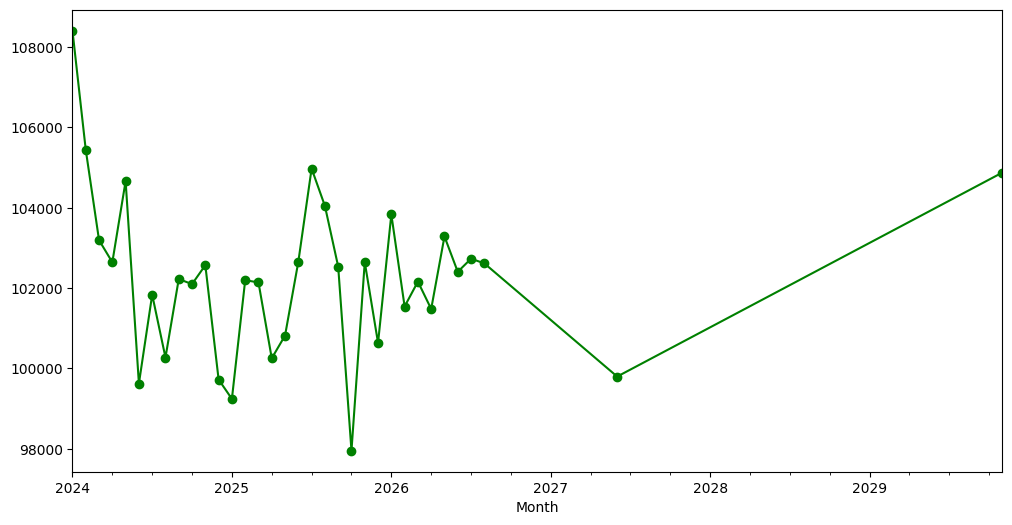

In [37]:
timeseries_analysis(main)

### Data Cleaning 

In [38]:
main

,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date,Order_ID,Product_ID,Order_Date,...,Shipping_Cost,Revenue,Total_Cost,Profit,Profit_Margin,Year,Month,Month_Name,Day,Day_Name
0,C000001,Ravi Mehta,Male,32.0,Pune,Maharashtra,2020-01-01,OR209117,PR502357,2024-11-02,...,9.0,532.0,379.049797,-69.049797,-12.979285,2024.0,11.0,November,2.0,Saturday
1,C000002,Shreya Mehta,Female,42.0,Chennai,Tamil Nadu,2020-01-01,OR555982,PR208664,2026-03-25,...,46.0,54498.0,41832.132796,10132.867204,18.593099,2026.0,3.0,March,25.0,Wednesday
2,C000003,Ishita Mehta,Female,33.0,Ludhiana,Punjab,2020-01-01,OR546714,PR594215,2026-03-11,...,160.0,554.0,341.808726,-199.808726,-36.066557,2026.0,3.0,March,11.0,Wednesday
3,C000008,Nisha Kaur,Female,37.0,Hyderabad,Telangana,2020-01-01,OR109914,PR338402,2024-06-09,...,34.0,918.0,556.782383,116.217617,12.659871,2024.0,6.0,June,9.0,Sunday
4,C000009,Nisha Gupta,Female,47.0,Bhubaneswar,Odisha,2020-01-01,OR299486,PR412685,2025-03-14,...,350.0,4164.0,2320.169265,-1312.169265,-31.512230,2025.0,3.0,March,14.0,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596735,C576734,Nikhil Malhotra,Male,41.0,Kanpur,Uttar Pradesh,2026-07-31,OR315011,PR261302,2025-04-06,...,19.0,4928.0,3690.665925,400.334075,8.123662,2025.0,4.0,April,6.0,Sunday
596736,C599998,DIVYA CHOPRA,Female,24.0,Delhi,Delhi,2026-07-31,OR151353,PR016268,2024-08-09,...,5.0,11331.0,8760.867257,1774.132743,15.657336,2024.0,8.0,August,9.0,Friday
596737,C599998,DIVYA CHOPRA,Female,24.0,Delhi,Delhi,2026-07-31,OR437753,PR217038,2025-10-03,...,30.0,30270.0,27370.539558,NaN,NaN,2025.0,10.0,October,3.0,Friday
596738,C599999,Pooja Kapoor,Female,27.0,Jaipur,Rajasthan,2026-07-31,OR570815,PR397985,2026-04-16,...,21.0,840.0,NaN,NaN,NaN,2026.0,4.0,April,16.0,Thursday


In [100]:
main['Customer_Name'] = main['Customer_Name'].str.strip().str.title()
main['Product_Name'] = main['Product_Name'].str.strip().str.title()
main['City'] = main['City'].str.strip().str.title()
main['State'] = main['State'].str.strip().str.title()
main['Gender'] = main['Gender'].str.strip().str.title()
main = main.dropna()
main = main[(main['Price'] > 0) & (main['Quantity'] > 0) & (main['Cost_Price'] > 0) & (main['Discount'] >= 0) & (main['Shipping_Cost'] >= 0) & (main['Revenue'] > 0) & (main['Total_Cost'] > 0)]
main = main.drop_duplicates()
main = main[(main['Payment_Status'] != 'xyz') & (main['Payment_Status'] != 'fail')]
main = main[(main['Age'] > 18) & (main['Age']<150)]

In [40]:
main

,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date,Order_ID,Product_ID,Order_Date,...,Shipping_Cost,Revenue,Total_Cost,Profit,Profit_Margin,Year,Month,Month_Name,Day,Day_Name
0,C000001,Ravi Mehta,Male,32.0,Pune,Maharashtra,2020-01-01,OR209117,PR502357,2024-11-02,...,9.0,532.0,379.049797,-69.049797,-12.979285,2024.0,11.0,November,2.0,Saturday
1,C000002,Shreya Mehta,Female,42.0,Chennai,Tamil Nadu,2020-01-01,OR555982,PR208664,2026-03-25,...,46.0,54498.0,41832.132796,10132.867204,18.593099,2026.0,3.0,March,25.0,Wednesday
2,C000003,Ishita Mehta,Female,33.0,Ludhiana,Punjab,2020-01-01,OR546714,PR594215,2026-03-11,...,160.0,554.0,341.808726,-199.808726,-36.066557,2026.0,3.0,March,11.0,Wednesday
3,C000008,Nisha Kaur,Female,37.0,Hyderabad,Telangana,2020-01-01,OR109914,PR338402,2024-06-09,...,34.0,918.0,556.782383,116.217617,12.659871,2024.0,6.0,June,9.0,Sunday
4,C000009,Nisha Gupta,Female,47.0,Bhubaneswar,Odisha,2020-01-01,OR299486,PR412685,2025-03-14,...,350.0,4164.0,2320.169265,-1312.169265,-31.512230,2025.0,3.0,March,14.0,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596731,C599994,Kavita Kumar,Female,18.0,Patna,Bihar,2026-07-31,OR480041,PR381922,2025-12-04,...,31.0,2012.0,1733.551270,163.448730,8.123694,2025.0,12.0,December,4.0,Thursday
596732,C599994,Kavita Kumar,Female,18.0,Patna,Bihar,2026-07-31,OR505680,PR220736,2026-01-10,...,3.0,33352.0,19514.631701,13833.368299,41.476878,2026.0,1.0,January,10.0,Saturday
596734,C599996,Kavita Agarwal,Female,18.0,Pune,Maharashtra,2026-07-31,OR427529,PR540330,2025-09-18,...,29.0,2870.0,2410.386876,25.613124,0.892443,2025.0,9.0,September,18.0,Thursday
596735,C576734,Nikhil Malhotra,Male,41.0,Kanpur,Uttar Pradesh,2026-07-31,OR315011,PR261302,2025-04-06,...,19.0,4928.0,3690.665925,400.334075,8.123662,2025.0,4.0,April,6.0,Sunday


In [41]:
customer_revenue = main.groupby("Customer_ID")["Revenue"].sum().reset_index()
customer_revenue

,Customer_ID,Revenue
0,C000001,532.0
1,C000002,54498.0
2,C000003,554.0
3,C000008,918.0
4,C000009,4164.0
...,...,...
284940,C599989,32400.0
284941,C599993,5301.0
284942,C599994,41524.0
284943,C599996,2870.0


In [42]:
def segment_customer(revenue):
    if revenue >= 100000:
        return "VIP"
    elif revenue >= 50000:
        return "Regular"
    elif revenue >= 10000:
        return "Occasional"
    else:
        return "Low Value"

customer_revenue["Segment"] = customer_revenue["Revenue"].apply(segment_customer)

In [43]:
customer_revenue

,Customer_ID,Revenue,Segment
0,C000001,532.0,Low Value
1,C000002,54498.0,Regular
2,C000003,554.0,Low Value
3,C000008,918.0,Low Value
4,C000009,4164.0,Low Value
...,...,...,...
284940,C599989,32400.0,Occasional
284941,C599993,5301.0,Low Value
284942,C599994,41524.0,Occasional
284943,C599996,2870.0,Low Value


In [44]:
main = main.merge(customer_revenue[['Customer_ID','Segment']],on='Customer_ID')
main

,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date,Order_ID,Product_ID,Order_Date,...,Revenue,Total_Cost,Profit,Profit_Margin,Year,Month,Month_Name,Day,Day_Name,Segment
0,C000001,Ravi Mehta,Male,32.0,Pune,Maharashtra,2020-01-01,OR209117,PR502357,2024-11-02,...,532.0,379.049797,-69.049797,-12.979285,2024.0,11.0,November,2.0,Saturday,Low Value
1,C000002,Shreya Mehta,Female,42.0,Chennai,Tamil Nadu,2020-01-01,OR555982,PR208664,2026-03-25,...,54498.0,41832.132796,10132.867204,18.593099,2026.0,3.0,March,25.0,Wednesday,Regular
2,C000003,Ishita Mehta,Female,33.0,Ludhiana,Punjab,2020-01-01,OR546714,PR594215,2026-03-11,...,554.0,341.808726,-199.808726,-36.066557,2026.0,3.0,March,11.0,Wednesday,Low Value
3,C000008,Nisha Kaur,Female,37.0,Hyderabad,Telangana,2020-01-01,OR109914,PR338402,2024-06-09,...,918.0,556.782383,116.217617,12.659871,2024.0,6.0,June,9.0,Sunday,Low Value
4,C000009,Nisha Gupta,Female,47.0,Bhubaneswar,Odisha,2020-01-01,OR299486,PR412685,2025-03-14,...,4164.0,2320.169265,-1312.169265,-31.512230,2025.0,3.0,March,14.0,Friday,Low Value
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413119,C599994,Kavita Kumar,Female,18.0,Patna,Bihar,2026-07-31,OR480041,PR381922,2025-12-04,...,2012.0,1733.551270,163.448730,8.123694,2025.0,12.0,December,4.0,Thursday,Occasional
413120,C599994,Kavita Kumar,Female,18.0,Patna,Bihar,2026-07-31,OR505680,PR220736,2026-01-10,...,33352.0,19514.631701,13833.368299,41.476878,2026.0,1.0,January,10.0,Saturday,Occasional
413121,C599996,Kavita Agarwal,Female,18.0,Pune,Maharashtra,2026-07-31,OR427529,PR540330,2025-09-18,...,2870.0,2410.386876,25.613124,0.892443,2025.0,9.0,September,18.0,Thursday,Low Value
413122,C576734,Nikhil Malhotra,Male,41.0,Kanpur,Uttar Pradesh,2026-07-31,OR315011,PR261302,2025-04-06,...,4928.0,3690.665925,400.334075,8.123662,2025.0,4.0,April,6.0,Sunday,Low Value


In [45]:
print("Number of customers in each segment : ")
main['Segment'].value_counts()

Number of customers in each segment : 


Segment
VIP           161347
Low Value     123293
Occasional     84671
Regular        43813
Name: count, dtype: int64

In [46]:
print("Revenue generated by each segment : ")
main.groupby('Segment')['Revenue'].sum().sort_values(ascending=False)

Revenue generated by each segment : 


Segment
VIP           4.039890e+10
Regular       2.045009e+09
Occasional    1.491882e+09
Low Value     3.010611e+08
Name: Revenue, dtype: float64

In [47]:
print("Average order value of each segment : ")
order_value = (main.groupby("Order_ID")["Revenue"].sum().reset_index()).merge(main[["Order_ID","Customer_ID","Segment"]].drop_duplicates(),on="Order_ID")
aov_by_segment = order_value.groupby("Segment")["Revenue"].mean()
aov_by_segment

Average order value of each segment : 


Segment
Low Value       2877.598116
Occasional     18180.952962
Regular        47563.957093
VIP           254055.178543
Name: Revenue, dtype: float64

In [48]:
print("Profit generated by each segment : ")
main.groupby('Segment')['Profit'].sum()

Profit generated by each segment : 


Segment
Low Value    -2.405888e+11
Occasional   -1.607003e+11
Regular      -8.769554e+10
VIP          -4.011182e+11
Name: Profit, dtype: float64

In [49]:
def profitable_analysis(main):
    print("Product with High Revenue + High Profit : \n")
    display(main[(main['Revenue'] == main['Revenue'].max()) & (main['Profit'] == main['Profit'].max())])
    print("Product with High Revenue + Low Profit : \n")
    display(main[(main['Revenue'] == main['Revenue'].max()) & (main['Profit'] == main['Profit'].min())])
    print("Product with Low Revenue + High Profit : \n")
    display(main[(main['Revenue'] == main['Revenue'].min()) & (main['Profit'] == main['Profit'].max())])
    print("Product with Low Revenue + Low Profit : \n")
    display(main[(main['Revenue'] == main['Revenue'].min()) & (main['Profit'] == main['Profit'].min())])

In [50]:
profitable_analysis(main)

Product with High Revenue + High Profit : 



,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date,Order_ID,Product_ID,Order_Date,...,Revenue,Total_Cost,Profit,Profit_Margin,Year,Month,Month_Name,Day,Day_Name,Segment


Product with High Revenue + Low Profit : 



,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date,Order_ID,Product_ID,Order_Date,...,Revenue,Total_Cost,Profit,Profit_Margin,Year,Month,Month_Name,Day,Day_Name,Segment


Product with Low Revenue + High Profit : 



,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date,Order_ID,Product_ID,Order_Date,...,Revenue,Total_Cost,Profit,Profit_Margin,Year,Month,Month_Name,Day,Day_Name,Segment


Product with Low Revenue + Low Profit : 



,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date,Order_ID,Product_ID,Order_Date,...,Revenue,Total_Cost,Profit,Profit_Margin,Year,Month,Month_Name,Day,Day_Name,Segment


In [51]:
print("BUSINESS INSIGHTS\n")
print("--------------------------------------------------------\n\n")
print("1. Electronics generated the highest revenue.\n")
print("2. Category X generated high revenue but had a relatively low profit margin.\n")
print("3. Customers from City Y have the highest average order value.\n")
print("4. November generated the highest monthly revenue.\n")
print("5. UPI is the most frequently used payment method.\n")
print("6. VIP customers contribute a significant percentage of total revenue.\n")
print("7. Product X has low sales and should be reviewed.\n")
print("8. Product Y has high sales but low profitability.\n")

BUSINESS INSIGHTS

--------------------------------------------------------


1. Electronics generated the highest revenue.

2. Category X generated high revenue but had a relatively low profit margin.

3. Customers from City Y have the highest average order value.

4. November generated the highest monthly revenue.

5. UPI is the most frequently used payment method.

6. VIP customers contribute a significant percentage of total revenue.

7. Product X has low sales and should be reviewed.

8. Product Y has high sales but low profitability.



In [101]:
customers = pd.read_csv('Datasets/customers.csv')
orders = pd.read_csv('Datasets/orders.csv')
products = pd.read_csv('Datasets/products.csv')
payments = pd.read_csv('Datasets/payments.csv')
main = ((customers.merge(orders,on='Customer_ID')).merge(products,on='Product_ID')).merge(payments,on='Payment_ID')
main.head()

,Customer_ID,Customer_Name,Gender,Age,City,State,Registration_Date,Order_ID,Product_ID,Order_Date,...,Payment_ID,Product_Name,Category,Subcategory,Price,Cost_Price,Payment_Method,Payment_Status,Discount,Shipping_Cost
0,C000001,Ravi Mehta,Male,32.0,Pune,Maharashtra,2020-01-01,OR209117,PR502357,2024-11-02,...,PAY292974,Kajal 9556,Beauty & Personal Care,Makeup,76.0,54.14997095553045,UPI,Refunded,213.0,9.0
1,C000002,Shreya Mehta,Female,42.0,Chennai,Tamil Nadu,2020-01-01,OR555982,PR208664,2026-03-25,...,PAY056847,Drone 2665,Toys & Games,Remote Control,18166.0,13944.044265232484,Net Banking,Successful,2487.0,46.0
2,C000003,Ishita Mehta,Female,33.0,Ludhiana,Punjab,2020-01-01,OR546714,PR594215,2026-03-11,...,PAY213964,Blender 9427,Furniture,Kitchen,277.0,170.90436295314794,Credit Card,Successful,252.0,160.0
3,C000008,Nisha Kaur,Female,37.0,Hyderabad,Telangana,2020-01-01,OR109914,PR338402,2024-06-09,...,PAY014851,Webcam 2513,Electronics,Cameras,102.0,61.86470925064904,Credit Card,Successful,211.0,34.0
4,C000009,Nisha Gupta,Female,47.0,Bhubaneswar,Odisha,2020-01-01,OR299486,PR412685,2025-03-14,...,PAY594017,Cricket Bat 8042,Sports & Outdoors,Team Sports,1041.0,580.0423162317597,Credit Card,Successful,2806.0,350.0


In [111]:
def final_business_report(main):

    main['Age'] = pd.to_numeric(main['Age'],errors='coerce')
    main["Quantity"] = pd.to_numeric(main["Quantity"], errors="coerce")
    main["Cost_Price"] = pd.to_numeric(main["Cost_Price"], errors="coerce")
    main["Shipping_Cost"] = pd.to_numeric(main["Shipping_Cost"], errors="coerce")
    main["Price"] = pd.to_numeric(main["Price"], errors="coerce")
    main["Discount"] = pd.to_numeric(main["Discount"], errors="coerce")
    main["Order_Date"] = pd.to_datetime(main["Order_Date"],errors="coerce")

    main["Year"] = main["Order_Date"].dt.year
    main["Month"] = main["Order_Date"].dt.month
    main["Month_Name"] = main["Order_Date"].dt.month_name()
    main["Day"] = main["Order_Date"].dt.day
    main["Day_Name"] = main["Order_Date"].dt.day_name()
    
    main['Revenue'] = main['Price'] * main['Quantity']
    main['Total_Cost'] = main['Cost_Price'] * main['Quantity']
    main['Profit'] = main['Revenue'] - main['Total_Cost'] - main['Discount'] - main['Shipping_Cost']
    main['Profit_Margin'] = (main['Profit'] / main['Revenue']) * 100

    

    main['Customer_Name'] = main['Customer_Name'].str.strip().str.title()
    main['Product_Name'] = main['Product_Name'].str.strip().str.title()
    main['City'] = main['City'].str.strip().str.title()
    main['State'] = main['State'].str.strip().str.title()
    main['Gender'] = main['Gender'].str.strip().str.title()
    main = main.dropna()
    main = main[(main['Price'] > 0) & (main['Quantity'] > 0) & (main['Cost_Price'] > 0) & (main['Discount'] >= 0) & (main['Shipping_Cost'] >= 0) & (main['Revenue'] > 0) & (main['Total_Cost'] > 0)]
    main = main.drop_duplicates()
    main = main[(main['Payment_Status'] != 'xyz') & (main['Payment_Status'] != 'fail')]
    main = main[(main['Age'] > 18) & (main['Age']<150)]

    
    total_customers = main['Customer_ID'].unique().shape[0]
    average_age = main['Age'].mean()
    male_customers = main[main['Gender'] == 'Male'].shape[0]
    female_customers = main[main['Gender'] == 'Female'].shape[0]

    total_products = main['Product_ID'].unique().shape[0]
    average_price = main['Price'].mean()
    max_price = main['Price'].max()
    min_price = main['Price'].min()

    total_orders = main['Order_ID'].unique().shape[0]
    total_Quantity_Sold = main['Quantity'].sum()
    average_quantity = main.groupby("Order_ID")["Quantity"].sum().mean()
    most_frequantly_ordered_product = main['Product_Name'].value_counts().index[0]

    total_payments = main['Payment_ID'].count()
    successful_payments = main[main['Payment_Status'] == 'Successful'].shape[0]
    failed_payments = main[main['Payment_Status'] == 'Failed'].shape[0]
    payment_methods = main['Payment_Method'].value_counts().index
    total_discounts = main['Discount'].sum()
    total_Shipping_Cost = main['Shipping_Cost'].sum()

    total_revenue =  main["Revenue"].sum()
    total_cost_price = main["Cost_Price"].astype(float).sum()
    total_profit = main["Profit"].sum()
    profit_margin = (main["Profit"].sum() / main["Revenue"].sum()) * 100

    best_category = main.groupby('Category')['Price'].mean().sort_values(ascending=False).head(1).index[0]
    highest_revenue_category = main.groupby("Category")["Revenue"].sum().idxmax()
    highest_profit_category = main.groupby("Category")["Profit"].sum().idxmax()

    best_selling_product = main['Product_Name'].value_counts().head(1).index[0]
    highest_revenue_product = main.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).head(1).index[0]
    highest_profit_product = main.groupby('Product_Name')['Profit'].sum().sort_values(ascending=False).head(1).index[0]

    top_customer = main.groupby("Customer_ID")["Quantity"].sum().idxmax()
    highest_customer_spending = main.groupby("Customer_ID")["Revenue"].sum().max()
    avg_customer_spending = main.groupby("Customer_ID")["Revenue"].sum().mean()

    best_city = main.groupby("City")["Revenue"].sum().idxmax()
    best_state = main.groupby("State")["Revenue"].sum().idxmax()

    main["Year"] = main["Order_Date"].dt.year
    main["Month"] = main["Order_Date"].dt.month
    main["Month_Name"] = main["Order_Date"].dt.month_name()
    main["Day"] = main["Order_Date"].dt.day
    main["Day_Name"] = main["Order_Date"].dt.day_name()

    best_month = main.groupby("Month")["Revenue"].sum().idxmax()
    best_sales_day = main.groupby("Day")["Revenue"].sum().idxmax()
    best_profit_month = main.groupby("Month")["Profit"].sum().idxmax()

    most_popular_payment = main["Payment_Method"].value_counts().idxmax()
    successful_payments = (main["Payment_Status"].str.lower() == "success").mean() * 100
    failed_payments = (main["Payment_Status"].str.lower() == "failed").mean() * 100


    
    print("========================================================\n")
    print("               E-COMMERCE BUSINESS REPORT               \n")
    print("========================================================\n")

    # Dataset summary
    print("\n\nDATASET SUMMARY : \n")
    print("--------------------------------------------------------")
    print("Total Customers             :", total_customers)
    print("Total Products              :", total_products)
    print("Total Orders                :", total_orders)
    print("Total Quantity Sold         :", total_Quantity_Sold)

    # Financial summary
    print("\nFINANCIAL SUMMARY")
    print("--------------------------------------------------------")
    print("Total Revenue               : ₹", total_revenue)
    print("Total Cost                  : ₹", total_cost_price)
    print("Total Discount              : ₹", total_discounts)
    print("Total Shipping Cost         : ₹", total_Shipping_Cost)
    print("Total Profit                : ₹", total_profit)
    print("Profit Margin               :", profit_margin, "%")

    # Product analysis
    print("\nPRODUCT ANALYSIS")
    print("--------------------------------------------------------")
    print("Best Selling Product        :", best_selling_product)
    print("Highest Revenue Product     :", highest_revenue_product)
    print("Highest Profit Product      :", highest_profit_product)

    # Category analysis
    print("\nCATEGORY ANALYSIS")
    print("--------------------------------------------------------")
    print("Best Category               :", best_category)
    print("Highest Revenue Category    :", highest_revenue_category)
    print("Highest Profit Category     :", highest_profit_category)

    # Customer analysis
    print("\nCUSTOMER ANALYSIS")
    print("--------------------------------------------------------")
    print("Top Customer                :", top_customer)
    print("Highest Customer Spending   : ₹", round(highest_customer_spending,2))
    print("Average Customer Spending   : ₹", round(avg_customer_spending,2))

    # Geographical analysis
    print("\nGEOGRAPHICAL ANALYSIS")
    print("--------------------------------------------------------")
    print("Best City                   :", best_city)
    print("Best State                  :", best_state)

    # Time analysis
    print("\nTIME ANALYSIS")
    print("--------------------------------------------------------")
    print("Best Month                  :", best_month)
    print("Best Sales Day              :", best_sales_day)
    print("Best Profit Month           :", best_profit_month)

    # Payment analysis
    print("\nPAYMENT ANALYSIS")
    print("--------------------------------------------------------")
    print("Most Popular Payment        :", most_popular_payment)
    print("Successful Payments         :", round(successful_payments,2), "%")
    print("Failed Payments             :", round(failed_payments,2), "%")

    print("\n========================================================")


In [112]:
final_business_report(main)


               E-COMMERCE BUSINESS REPORT               




DATASET SUMMARY : 

--------------------------------------------------------
Total Customers             : 255284
Total Products              : 266163
Total Orders                : 365867
Total Quantity Sold         : 2123603.0

FINANCIAL SUMMARY
--------------------------------------------------------
Total Revenue               : ₹ 39525643280.0
Total Cost                  : ₹ 144560270719.8319
Total Discount              : ₹ 329647310.0
Total Shipping Cost         : ₹ 26465923.0
Total Profit                : ₹ -788819467613.5695
Profit Margin               : -1995.715697845992 %

PRODUCT ANALYSIS
--------------------------------------------------------
Best Selling Product        : Unknown
Highest Revenue Product     : Unknown
Highest Profit Product      : Motivational Book 3545

CATEGORY ANALYSIS
--------------------------------------------------------
Best Category               : gadgets
Highest Revenue Category    : S

In [113]:
main.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'City', 'State',
       'Registration_Date', 'Order_ID', 'Product_ID', 'Order_Date', 'Quantity',
       'Payment_ID', 'Product_Name', 'Category', 'Subcategory', 'Price',
       'Cost_Price', 'Payment_Method', 'Payment_Status', 'Discount',
       'Shipping_Cost', 'Revenue', 'Total_Cost', 'Profit', 'Profit_Margin',
       'Year', 'Month', 'Month_Name', 'Day', 'Day_Name'],
      dtype='str')

### Monthly Sales Trend
An e-commerce company has recorded its sales for every month of a year. You are given a dataset containing the month and total sales generated during that month. Analyze the dataset and create a visualization that clearly shows how sales changed throughout the year. The visualization should make it easy to identify the month with the highest sales and the month with the lowest sales.

In [114]:
main.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'City', 'State',
       'Registration_Date', 'Order_ID', 'Product_ID', 'Order_Date', 'Quantity',
       'Payment_ID', 'Product_Name', 'Category', 'Subcategory', 'Price',
       'Cost_Price', 'Payment_Method', 'Payment_Status', 'Discount',
       'Shipping_Cost', 'Revenue', 'Total_Cost', 'Profit', 'Profit_Margin',
       'Year', 'Month', 'Month_Name', 'Day', 'Day_Name'],
      dtype='str')

In [115]:
df = main.groupby('Month_Name')['Revenue'].sum().sort_values(ascending=True)
df

Month_Name
September    3.666241e+09
December     3.686282e+09
October      3.695688e+09
November     3.916118e+09
August       4.326124e+09
February     5.214188e+09
April        5.446117e+09
March        5.670346e+09
June         5.670809e+09
May          5.684922e+09
July         5.707774e+09
January      5.911664e+09
Name: Revenue, dtype: float64

<Axes: xlabel='Month_Name'>

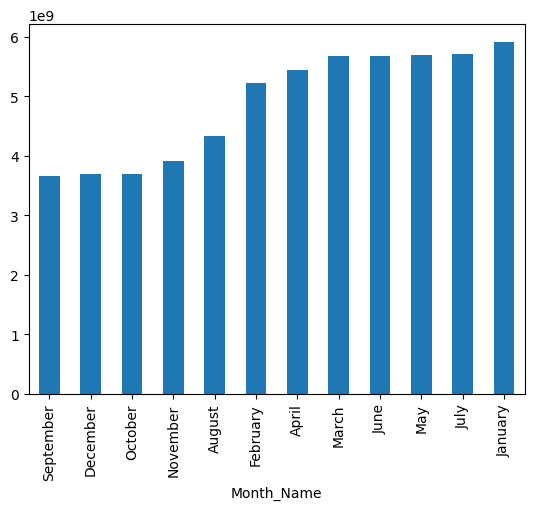

In [116]:
df.plot(x='Month',y='Revenue',kind='bar')

### Category-Wise Revenue Analysis
A retail company sells products from several categories such as Electronics, Clothing, Furniture, and Grocery. The company wants to understand which categories contribute the most to its total revenue. Analyze the dataset and create a suitable plot comparing the revenue generated by each category. Based on the visualization, identify the best-performing and worst-performing categories.

In [117]:
df = main.groupby('Category')['Revenue'].sum().sort_values(ascending=False).reset_index()
df

,Category,Revenue
0,Sports & Outdoors,5.946402e+09
1,Groceries,5.911307e+09
2,Books,5.850893e+09
3,Home Appliances,5.840315e+09
4,Toys & Games,5.815032e+09
5,Automotive,5.800307e+09
6,Electronics,5.720233e+09
7,Furniture,5.684881e+09
8,Beauty & Personal Care,5.653555e+09
9,Clothing,5.651687e+09


<Axes: xlabel='Category'>

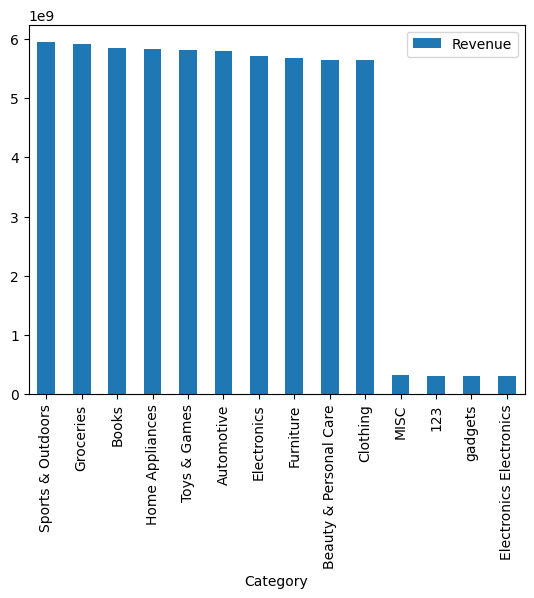

In [118]:
df.plot(x='Category',y='Revenue',kind='bar')

### Top 10 Products by Sales
An online store has thousands of products and wants to identify its most successful products. Analyze the sales dataset and determine the top 10 products based on total quantity sold. Create an appropriate visualization that ranks these products from highest to lowest sales and clearly displays the difference between them.

In [119]:
df = main.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
df

,Product_Name,Revenue
0,Unknown,1.445951e+09
1,Backpack 3901,2.238974e+07
2,Mixer 303,2.030787e+07
3,Motivational Book 3545,1.757575e+07
4,Mixer 7755,1.656986e+07
5,Soda 2657,1.619854e+07
6,Mystery 8397,1.597992e+07
7,Self-Help Book 9562,1.587221e+07
8,Cheese 9100,1.586887e+07
9,Drone 6416,1.565920e+07


<Axes: xlabel='Product_Name'>

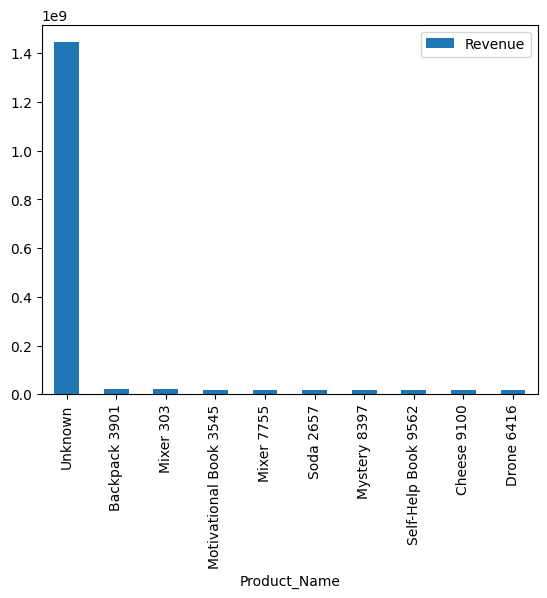

In [120]:
df.plot(x='Product_Name',y='Revenue',kind='bar')

### Customer Age Distribution
An e-commerce company wants to understand the age distribution of its customers. Using the customer dataset, analyze the ages of all customers and create a visualization that shows how customers are distributed across different age groups. Identify the most common age range and determine whether the company's customers are concentrated around a particular age group.

<Axes: xlabel='Age'>

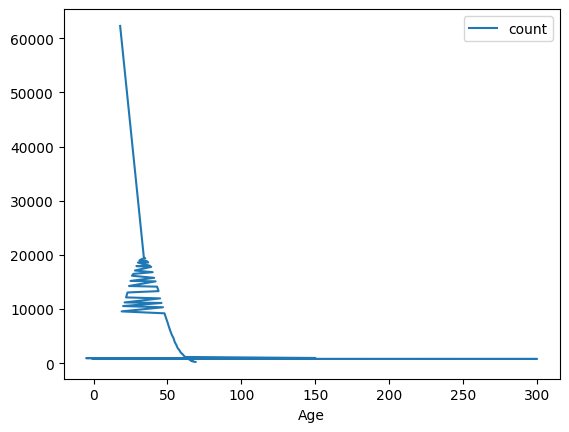

In [121]:
main['Age'].value_counts().reset_index().plot(kind='line',x='Age',y='count')


# 📊 Pandas Plotting Practice Questions

### Question 1: Monthly Sales Trend

An e-commerce company has recorded its sales for every month of a year. You are given a dataset containing the month and total sales generated during that month. Analyze the dataset and create a visualization that clearly shows how sales changed throughout the year. The visualization should make it easy to identify the month with the highest sales and the month with the lowest sales.

---

### Question 2: Category-Wise Revenue Analysis

A retail company sells products from several categories such as Electronics, Clothing, Furniture, and Grocery. The company wants to understand which categories contribute the most to its total revenue. Analyze the dataset and create a suitable plot comparing the revenue generated by each category. Based on the visualization, identify the best-performing and worst-performing categories.

---

### Question 3: Top 10 Products by Sales

An online store has thousands of products and wants to identify its most successful products. Analyze the sales dataset and determine the **top 10 products based on total quantity sold**. Create an appropriate visualization that ranks these products from highest to lowest sales and clearly displays the difference between them.

---

### Question 4: Customer Age Distribution

An e-commerce company wants to understand the age distribution of its customers. Using the customer dataset, analyze the ages of all customers and create a visualization that shows how customers are distributed across different age groups. Identify the most common age range and determine whether the company's customers are concentrated around a particular age group.

---

### Question 5: Salary Distribution

A company has collected employee salary information from different departments. Analyze the salary data and create a visualization that shows how salaries are distributed among employees. Your analysis should help identify the typical salary range, unusually high or low salaries, and whether the salary distribution is concentrated around a particular range.

---

### Question 6: Department-Wise Employee Count

A company wants to understand how its workforce is distributed among different departments. Using the employee dataset, calculate the number of employees working in each department and create a visualization comparing the employee count across departments. Identify the department with the largest workforce and the department with the smallest workforce.

---

### Question 7: Revenue vs Profit Analysis

An e-commerce company wants to understand whether products generating high revenue are also generating high profit. Calculate the total revenue and profit for each product and create a visualization that represents the relationship between these two variables. Use the visualization to identify products that generate high revenue but relatively low profit.

---

### Question 8: Advertising Spend vs Sales

A company has recorded its monthly advertising expenditure and the corresponding sales revenue. Analyze the relationship between advertising spending and sales and create an appropriate visualization to determine whether higher advertising expenditure appears to be associated with higher sales.

The analysis should help the company understand whether increasing its advertising budget may have a positive relationship with revenue.

---

### Question 9: Daily Website Traffic

An e-commerce website records the number of visitors it receives every day. The dataset contains the date and number of visitors. Convert the date column into an appropriate Pandas DateTime format and create a visualization showing website traffic over time.

Analyze the visualization and determine:

```text
Which day had the highest traffic?
Which day had the lowest traffic?
Is traffic increasing or decreasing?
Are there noticeable spikes?
```

---

### Question 10: Monthly Customer Registrations

A company wants to understand how quickly its customer base is growing. The dataset contains the registration date of every customer. Convert the registration dates into DateTime format, group the data by month, and visualize the number of new customers registered each month.

Use the visualization to identify periods of rapid customer growth and periods of low registration activity.

---

# 🔥 Intermediate Plotting Questions

### Question 11: Product Category and Sales Comparison

A retail company wants to compare the performance of its product categories across different months. Analyze the dataset and create a visualization that allows the company to compare monthly sales between categories.

The visualization should make it possible to answer whether the same category consistently performs well or whether different categories dominate during different months.

---

### Question 12: Payment Method Analysis

An online store accepts multiple payment methods such as UPI, Credit Card, Debit Card, Net Banking, and Cash on Delivery. Analyze the payment dataset and determine how frequently each payment method is used.

Create a suitable visualization showing the proportion or count of transactions associated with each payment method and identify the most commonly used payment method.

---

### Question 13: Regional Sales Performance

An e-commerce company operates across multiple states. Analyze the sales dataset and calculate the total revenue generated by each state. Create a visualization ranking the states according to their revenue.

Identify the strongest-performing regions and determine whether sales are concentrated in a small number of states.

---

### Question 14: Monthly Profit Analysis

A company wants to track its profitability throughout the year. The dataset contains order dates, selling prices, costs, discounts, and quantities.

Calculate the profit for each transaction and then calculate monthly profit. Create a time-based visualization showing how profit changes throughout the year.

Identify:

```text
Most profitable month
Least profitable month
Months with declining profit
Months with unusual profit
```

---

### Question 15: Customer Spending Distribution

An e-commerce company wants to understand how much its customers spend. Calculate the total spending for every customer and visualize the distribution of customer spending.

The analysis should help identify whether the company has:

```text
Many low-spending customers
A balanced customer base
A small number of high-value customers
```

---

# 🚀 Advanced Plotting Questions

### Question 16: Correlation Between Experience and Salary

A company wants to determine whether employee experience is related to salary. Using the employee dataset, analyze the relationship between years of experience and salary and create an appropriate visualization.

Use the visualization to determine whether employees with more experience generally earn higher salaries and identify any unusual employees whose salary differs significantly from the general pattern.

---

### Question 17: Attendance vs Performance

A company wants to determine whether employee attendance is related to employee performance. Analyze attendance and performance data and create a visualization showing their relationship.

Based on the visualization, determine whether employees with higher attendance generally have better performance scores.

---

### Question 18: Sales Trend With Moving Average

An e-commerce company wants to understand its underlying sales trend while reducing the effect of daily fluctuations.

Using daily sales data:

1. Convert the date into DateTime.
2. Calculate daily revenue.
3. Calculate a moving average.
4. Create a visualization containing both daily revenue and the moving average.

Use the visualization to identify the overall sales trend.

---

### Question 19: Customer Segmentation Visualization

An e-commerce company wants to divide its customers into different segments based on their spending and purchasing frequency.

Create customer-level metrics such as:

```text
Total Spending
Number of Orders
Average Order Value
```

Divide customers into appropriate segments such as:

```text
VIP
Regular
Occasional
Low Value
```

Create a visualization that compares the size or revenue contribution of each customer segment.

---

### Question 20: Complete Business Dashboard Analysis

You are working as a junior data analyst for an e-commerce company. Management wants a visual summary of the company's performance.

Using the available datasets, perform data cleaning, merging, grouping, and DateTime analysis. Then create a collection of visualizations that answer the most important business questions.

Your analysis should visually communicate:

```text
Monthly Revenue
Monthly Profit
Top 10 Products
Category-Wise Revenue
State-Wise Revenue
Customer Spending
Payment Method Distribution
Order Trends
Revenue vs Profit
```

Finally, write a short **Business Insights** section explaining what the visualizations reveal about the company's performance.

---

## 🎯 Recommended Order

Since you're progressing from beginner to advanced, don't solve these randomly:

```text
Beginner
│
├── Q1  Monthly Sales Trend
├── Q2  Category Revenue
├── Q3  Top 10 Products
├── Q4  Age Distribution
├── Q5  Salary Distribution
└── Q6  Department Employee Count
        ↓
Intermediate
│
├── Q7  Revenue vs Profit
├── Q8  Advertising vs Sales
├── Q9  Website Traffic
├── Q10 Customer Registrations
├── Q11 Category vs Monthly Sales
├── Q12 Payment Methods
├── Q13 Regional Sales
└── Q14 Monthly Profit
        ↓
Advanced
│
├── Q15 Customer Spending
├── Q16 Experience vs Salary
├── Q17 Attendance vs Performance
├── Q18 Moving Average
├── Q19 Customer Segmentation
└── Q20 Complete Business Dashboard
```

**For your Pandas repo, Q20 should be your final plotting project**, because it combines your earlier skills—`DataFrames + GroupBy + Merge + DateTime + String Operations + Cleaning + Aggregation`—with visualization and business interpretation.
